# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

DATA_PATH = "../data/raw/Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
# Verify the data loaded correctly by displaying shape and a sample

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

df.sample(5)

Dataset shape: 48204 rows x 9 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
36688,NaN,294.35,0.00,0.0,90,Drizzle,light intensity drizzle,2017-08-27 17:00:00,4730
16703,NaN,300.72,0.00,0.0,1,Clear,sky is clear,2015-07-19 18:00:00,4046
2245,NaN,270.72,0.00,0.0,90,Mist,mist,2012-12-20 19:00:00,3270
14482,NaN,285.23,0.51,0.0,90,Mist,mist,2014-05-20 00:00:00,547
34370,NaN,289.35,0.00,0.0,1,Clear,sky is clear,2017-06-09 05:00:00,2798


In [4]:
# Document data source details

data_source_report = {
    "source": "UCI Machine Learning Repository",
    "acquisition_method": "CSV file download",
    "date_acquired": "2026",
    "issues_encountered": []
}

print(data_source_report)

{'source': 'UCI Machine Learning Repository', 'acquisition_method': 'CSV file download', 'date_acquired': '2026', 'issues_encountered': []}


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
# Describe dataset structure and schema
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset info:")
df.info()

print("\nDataset info:")
df.info()

schema_notes = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Role": [
        "Holiday name",
        "Temperature feature",
        "Rain feature",
        "Snow feature",
        "Cloud coverage feature",
        "Weather category",
        "Weather details",
        "Date and time field",
        "Target variable"
    ]
})

display(schema_notes)

print("\nSchema summary:")

print("Insight:")
print("- The dataset contains a mix of numerical, categorical, and datetime fields.")
print("- 'traffic_volume' is the target variable, while the rest are potential predictors.")
print("- 'date_time' will need to be converted into time-based features for modelling.")

Dataset shape: (48204, 9)

Column names:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']

Data types:


,dtype
holiday,str
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,str
weather_description,str
date_time,str
traffic_volume,int64



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp         

,Column,Data Type,Role
0,holiday,str,Holiday name
1,temp,float64,Temperature feature
2,rain_1h,float64,Rain feature
3,snow_1h,float64,Snow feature
4,clouds_all,int64,Cloud coverage feature
5,weather_main,str,Weather category
6,weather_description,str,Weather details
7,date_time,str,Date and time field
8,traffic_volume,int64,Target variable



Schema summary:
Insight:
- The dataset contains a mix of numerical, categorical, and datetime fields.
- 'traffic_volume' is the target variable, while the rest are potential predictors.
- 'date_time' will need to be converted into time-based features for modelling.


In [6]:
# Generate descriptive statistics for numerical columns
numeric_summary = df.describe().T
numeric_summary["range"] = numeric_summary["max"] - numeric_summary["min"]
display(numeric_summary)

print("Insights from numerical summary:")
print("- Traffic volume has a wide spread, which suggests both low-traffic and peak-traffic periods are present.")
print("- Rain and snow are highly skewed because many observations are zero while a few are much larger.")
print("- Temperature and cloud cover vary enough to be useful candidate predictors.")

,count,mean,std,min,25%,50%,75%,max,range
temp,48204.0,281.205870,13.338232,0.0,272.16,282.45,291.806,310.07,310.07
rain_1h,48204.0,0.334264,44.789133,0.0,0.00,0.00,0.000,9831.30,9831.30
snow_1h,48204.0,0.000222,0.008168,0.0,0.00,0.00,0.000,0.51,0.51
clouds_all,48204.0,49.362231,39.015750,0.0,1.00,64.00,90.000,100.00,100.00
traffic_volume,48204.0,3259.818355,1986.860670,0.0,1193.00,3380.00,4933.000,7280.00,7280.00


Insights from numerical summary:
- Traffic volume has a wide spread, which suggests both low-traffic and peak-traffic periods are present.
- Rain and snow are highly skewed because many observations are zero while a few are much larger.
- Temperature and cloud cover vary enough to be useful candidate predictors.


In [7]:
# Generate descriptive statistics for categorical columns
categorical_summary = df.describe(include="object").T
display(categorical_summary)

print("Insights from categorical summary:")
print("- 'holiday' is dominated by the non-holiday category, so holidays are relatively rare.")
print("- Weather categories repeat often, which makes them suitable for encoding in later phases.")
print("- 'weather_description' is more detailed than 'weather_main', so it may add extra signal but could also add redundancy.")

/var/folders/t_/cvdyvf_d0053vkq8fjs4dvzr0000gn/T/ipykernel_43549/15764478.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_summary = df.describe(include="object").T


,count,unique,top,freq
holiday,61,11,Labor Day,7
weather_main,48204,11,Clouds,15164
weather_description,48204,38,sky is clear,11665
date_time,48204,40575,2013-04-18 22:00:00,6


Insights from categorical summary:
- 'holiday' is dominated by the non-holiday category, so holidays are relatively rare.
- Weather categories repeat often, which makes them suitable for encoding in later phases.
- 'weather_description' is more detailed than 'weather_main', so it may add extra signal but could also add redundancy.


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

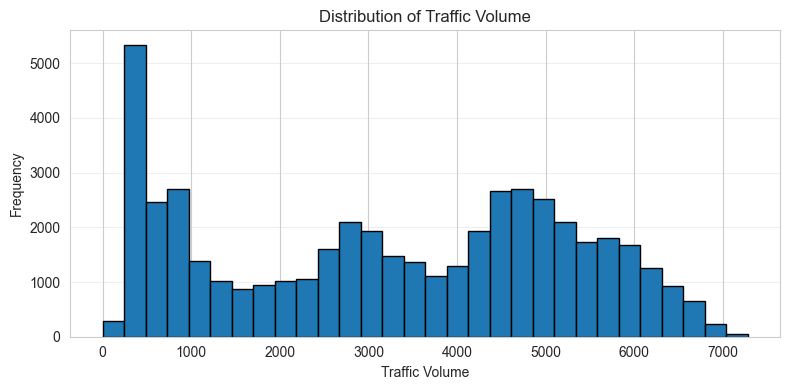

Insight:
- Traffic volume is not perfectly symmetric, so extreme low/high periods exist.
- This supports checking outliers and considering non-linear models later.


In [8]:
# Univariate analysis with cleaner visuals and short interpretations
df["date_time"] = pd.to_datetime(df["date_time"])

df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month

plt.figure(figsize=(8, 4))
df["traffic_volume"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic volume is not perfectly symmetric, so extreme low/high periods exist.")
print("- This supports checking outliers and considering non-linear models later.")

In [9]:
# Keep a single datetime conversion step and confirm it worked
df["date_time"] = pd.to_datetime(df["date_time"])

print("date_time converted successfully:", pd.api.types.is_datetime64_any_dtype(df["date_time"]))
print("Date range:", df["date_time"].min(), "to", df["date_time"].max())

date_time converted successfully: True
Date range: 2012-10-02 09:00:00 to 2018-09-30 23:00:00


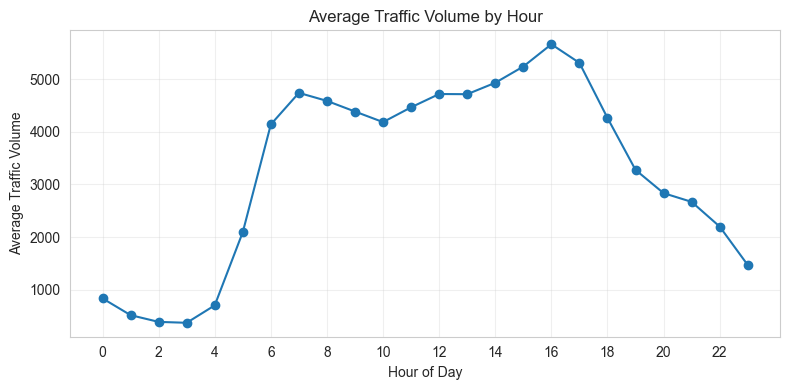

Insight:
- Traffic clearly changes by hour, indicating strong intraday patterns.
- Peak periods likely correspond to commuting times, so hour is an important feature.


In [10]:
# Traffic by hour
hourly = df.groupby("hour")["traffic_volume"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic clearly changes by hour, indicating strong intraday patterns.")
print("- Peak periods likely correspond to commuting times, so hour is an important feature.")

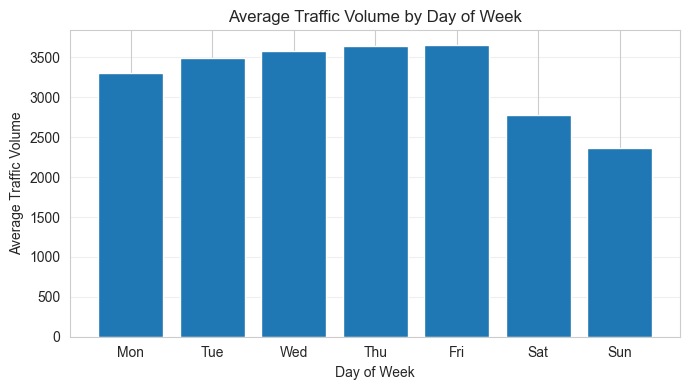

Insight:
- Weekday traffic is generally higher than weekend traffic.
- This suggests commuter behaviour is an important driver of traffic volume.


In [11]:
# Traffic by day of week
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df.groupby("day_of_week")["traffic_volume"].mean().reindex(range(7))

plt.figure(figsize=(7, 4))
plt.bar(day_labels, dow.values)
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Traffic Volume")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- Weekday traffic is generally higher than weekend traffic.")
print("- This suggests commuter behaviour is an important driver of traffic volume.")

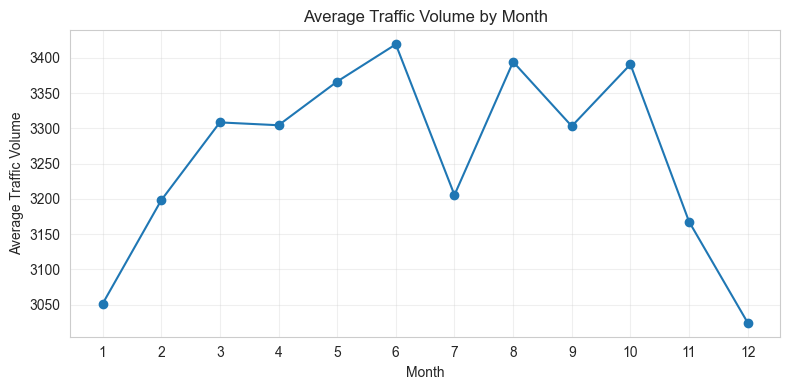

Insight:
- Traffic varies across months, which suggests seasonality.
- Month-based features may help the model capture longer-term temporal changes.


In [12]:
# Traffic by month
monthly = df.groupby("month")["traffic_volume"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic varies across months, which suggests seasonality.")
print("- Month-based features may help the model capture longer-term temporal changes.")

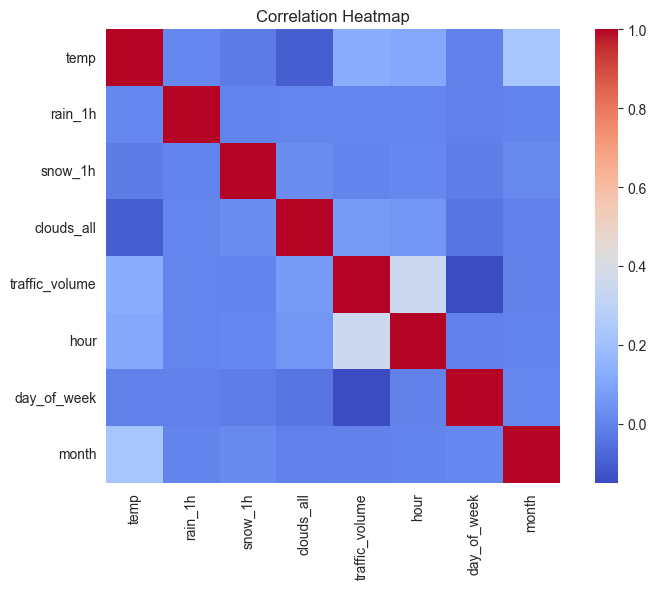

Insight:
- Time-related variables and weather variables show different strengths of association with traffic volume.
- Correlation helps identify broad linear relationships, but weak correlation does not mean a feature is useless for non-linear models.


In [13]:
# Bivariate / multivariate analysis
numeric_corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_corr,
    annot=False,
    cmap="coolwarm",
    cbar=True,
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Time-related variables and weather variables show different strengths of association with traffic volume.")
print("- Correlation helps identify broad linear relationships, but weak correlation does not mean a feature is useless for non-linear models.")

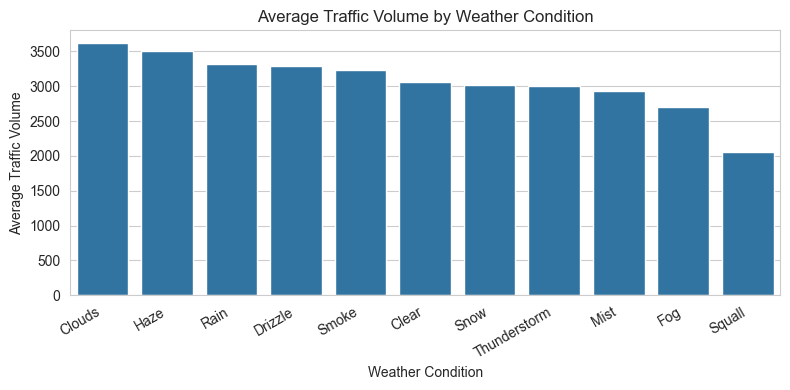

Insight:
- Traffic differs across weather categories, although the pattern is less dominant than time-based effects.
- Weather should still be retained because it may interact with time features.


In [14]:
# Average traffic by main weather category
weather_order = (
    df.groupby("weather_main")["traffic_volume"]
      .mean()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=df,
    x="weather_main",
    y="traffic_volume",
    order=weather_order,
    estimator=np.mean,
    errorbar=None
)
plt.xticks(rotation=30, ha="right")
plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic differs across weather categories, although the pattern is less dominant than time-based effects.")
print("- Weather should still be retained because it may interact with time features.")

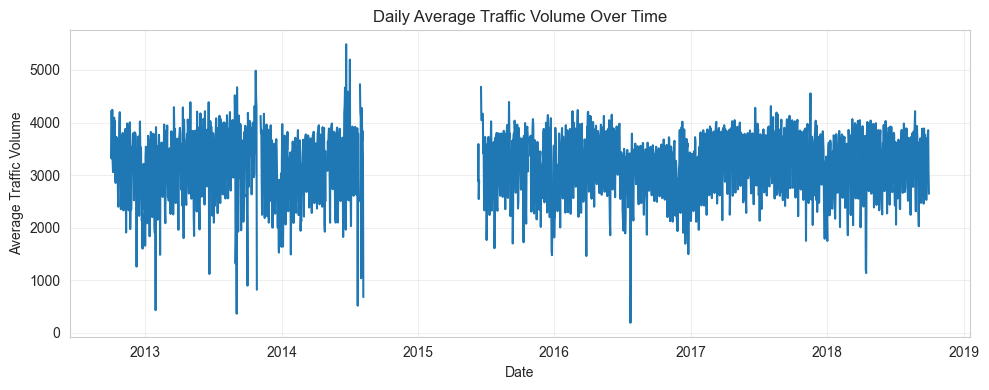

Insight:
- The series changes over time and is not random noise.
- This supports the idea that temporal structure is central to forecasting traffic volume.


In [15]:
# Traffic volume over time (sampled to reduce clutter)
df = df.sort_values("date_time").copy()
daily_traffic = df.set_index("date_time")["traffic_volume"].resample("D").mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_traffic.index, daily_traffic.values)
plt.title("Daily Average Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Average Traffic Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- The series changes over time and is not random noise.")
print("- This supports the idea that temporal structure is central to forecasting traffic volume.")

In [16]:
# Document initial insights and hypotheses in a cleaner summary table
initial_insights = pd.DataFrame({
    "Area": [
        "Time patterns",
        "Weekday vs weekend",
        "Seasonality",
        "Weather",
        "Modelling implication"
    ],
    "Insight": [
        "Traffic changes strongly by hour, indicating clear intraday behaviour.",
        "Weekdays tend to have higher traffic than weekends.",
        "Monthly variation suggests seasonal effects.",
        "Weather conditions influence traffic, but less strongly than time-based features.",
        "Time-derived features should be prioritised in Phase 3 and Phase 4."
    ]
})

display(initial_insights)

,Area,Insight
0,Time patterns,"Traffic changes strongly by hour, indicating c..."
1,Weekday vs weekend,Weekdays tend to have higher traffic than week...
2,Seasonality,Monthly variation suggests seasonal effects.
3,Weather,"Weather conditions influence traffic, but less..."
4,Modelling implication,Time-derived features should be prioritised in...


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [17]:
# Check missing values and comment on their impact
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing Count", ascending=False)

display(missing_report)

print("Insight:")
if (missing_report["Missing Count"] > 0).any():
    print("- Missing values exist and must be handled in Phase 3 before modelling.")
    print("- Columns with missing values should be imputed using strategies appropriate to their data type.")
else:
    print("- No missing values were detected, so missing-data handling in Phase 3 will be minimal.")

,Missing Count,Missing %
holiday,48143,99.87
temp,0,0.00
rain_1h,0,0.00
snow_1h,0,0.00
clouds_all,0,0.00
weather_main,0,0.00
weather_description,0,0.00
date_time,0,0.00
traffic_volume,0,0.00
hour,0,0.00


Insight:
- Missing values exist and must be handled in Phase 3 before modelling.
- Columns with missing values should be imputed using strategies appropriate to their data type.


In [18]:
# Check duplicate records
duplicates = df.duplicated().sum()
duplicate_pct = round((duplicates / len(df)) * 100, 4)

print(f"Duplicate rows: {duplicates}")
print(f"Duplicate percentage: {duplicate_pct}%")

print("Insight:")
if duplicates > 0:
    print("- Duplicate rows are present and should be removed in Phase 3 to avoid biasing the model.")
else:
    print("- No duplicate rows were found, which reduces the need for record-level deduplication.")

Duplicate rows: 17
Duplicate percentage: 0.0353%
Insight:
- Duplicate rows are present and should be removed in Phase 3 to avoid biasing the model.


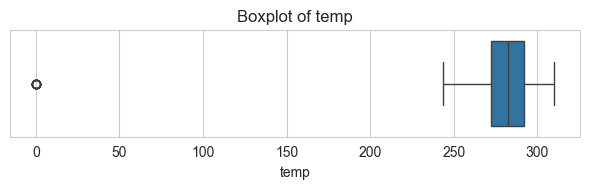

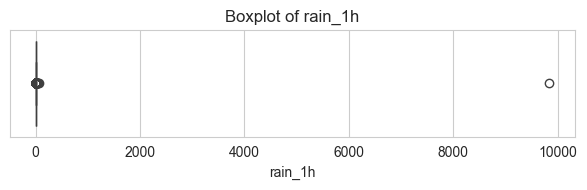

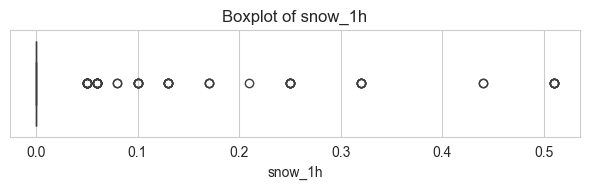

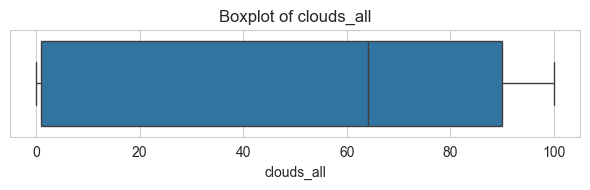

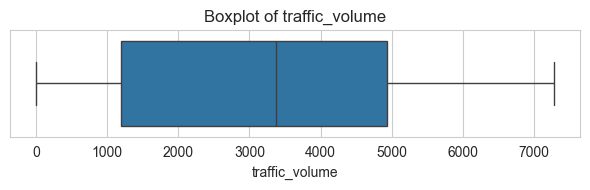

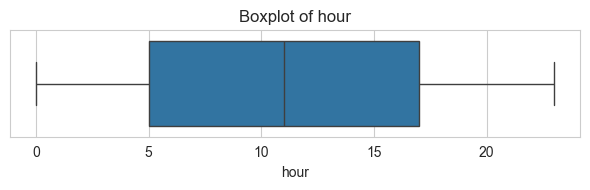

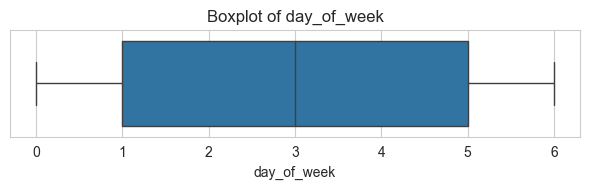

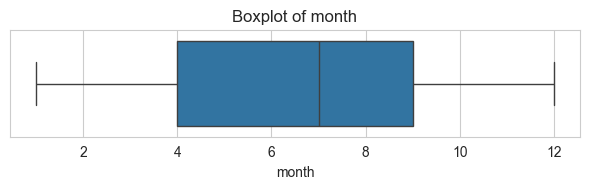

,Outlier Count
temp,10
rain_1h,3467
snow_1h,63
clouds_all,0
traffic_volume,0
hour,0
day_of_week,0
month,0


Phase 2 Summary Report


,Check,Conclusion
0,Structure and schema reviewed,Yes - mixed data types identified.
1,Descriptive statistics reviewed,Yes - numerical spread and skewness observed.
2,Categorical distributions reviewed,Yes - categorical weather and holiday features...
3,Missing values checked,Completed - use imputation only where needed.
4,Duplicates checked,Completed - 17 duplicate rows detected.
5,Outliers checked,Completed - some numerical variables show extr...
6,Encoding needed?,Yes - categorical columns will need encoding.
7,Ready for Phase 3?,"Yes - dataset is ready for cleaning, transform..."


Phase 3 Starting Point:
- Handle missing values using suitable imputation methods.
- Remove duplicate rows if present.
- Treat outliers carefully for selected numerical columns.
- Encode categorical features and create time-based features for modelling.


In [19]:
# Detect outliers and create a short Phase 3 starting report
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

outlier_report = {}
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = outlier_count

outlier_report = pd.DataFrame.from_dict(
    outlier_report,
    orient="index",
    columns=["Outlier Count"]
)
display(outlier_report)

phase2_summary = pd.DataFrame({
    "Check": [
        "Structure and schema reviewed",
        "Descriptive statistics reviewed",
        "Categorical distributions reviewed",
        "Missing values checked",
        "Duplicates checked",
        "Outliers checked",
        "Encoding needed?",
        "Ready for Phase 3?"
    ],
    "Conclusion": [
        "Yes - mixed data types identified.",
        "Yes - numerical spread and skewness observed.",
        "Yes - categorical weather and holiday features identified.",
        "Completed - use imputation only where needed.",
        f"Completed - {duplicates} duplicate rows detected.",
        "Completed - some numerical variables show extreme values.",
        "Yes - categorical columns will need encoding.",
        "Yes - dataset is ready for cleaning, transformation, and feature engineering."
    ]
})

print("Phase 2 Summary Report")
display(phase2_summary)

print("Phase 3 Starting Point:")
print("- Handle missing values using suitable imputation methods.")
print("- Remove duplicate rows if present.")
print("- Treat outliers carefully for selected numerical columns.")
print("- Encode categorical features and create time-based features for modelling.")

## Improved Visual Analysis (Cleaner + Insights)

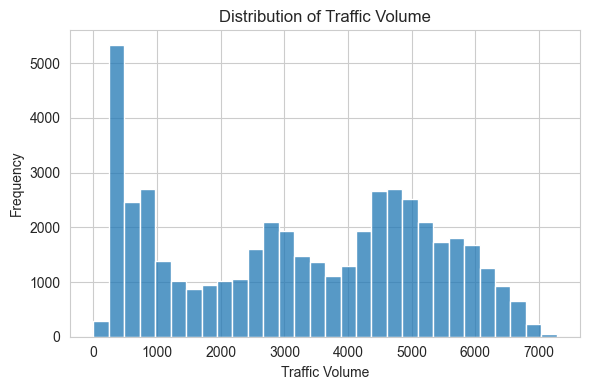

Insight:
- Traffic volume shows high variability.
- The spread suggests potential outliers and skewness.



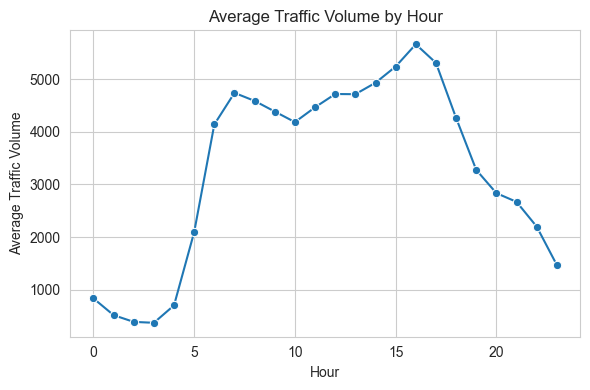

Insight:
- Traffic peaks during morning and evening rush hours.
- Traffic is lowest during late night hours.



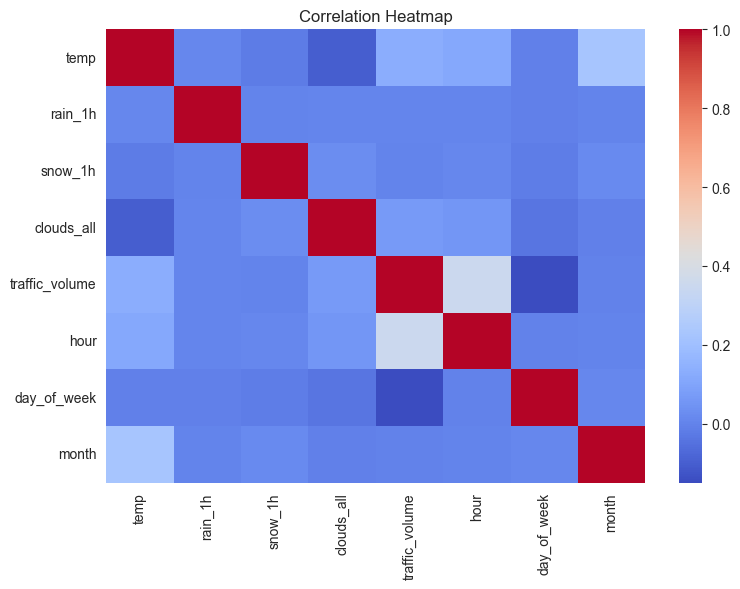

Insight:
- Some features show moderate relationships with traffic volume.
- Weak correlations do not mean features are useless for non-linear models.



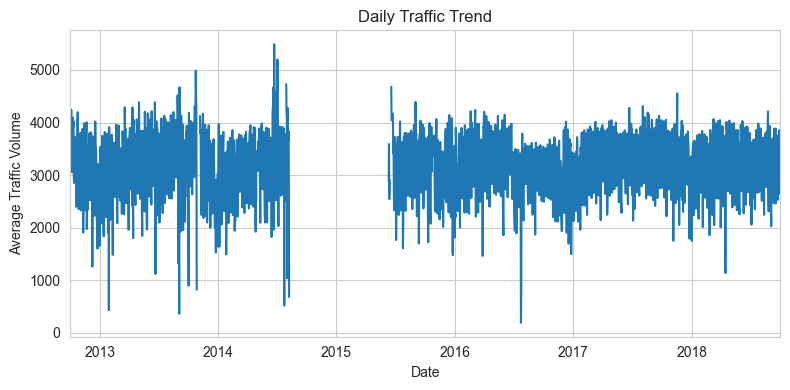

Insight:
- Aggregated data reveals clearer trends than raw data.
- Traffic shows temporal variation over time.


In [20]:
# Clean and simplified visual analysis with insights

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime is correct
df["date_time"] = pd.to_datetime(df["date_time"])

# --- 1. Traffic Distribution ---
plt.figure(figsize=(6,4))
sns.histplot(df["traffic_volume"], bins=30)
plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic volume shows high variability.")
print("- The spread suggests potential outliers and skewness.\n")


# --- 2. Traffic by Hour ---
hourly_avg = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(6,4))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Traffic Volume")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Traffic peaks during morning and evening rush hours.")
print("- Traffic is lowest during late night hours.\n")


# --- 3. Correlation Heatmap ---
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Some features show moderate relationships with traffic volume.")
print("- Weak correlations do not mean features are useless for non-linear models.\n")


# --- 4. Traffic Over Time (Smoothed) ---
daily = df.set_index("date_time").resample("D")["traffic_volume"].mean()

plt.figure(figsize=(8,4))
daily.plot()
plt.title("Daily Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Average Traffic Volume")
plt.tight_layout()
plt.show()

print("Insight:")
print("- Aggregated data reveals clearer trends than raw data.")
print("- Traffic shows temporal variation over time.")